# CMAPSS Data & Feature Engineering Pipeline
**SIH Problem Statement 54 (Team AeroTwin) - Person 1**

This notebook performs Exploratory Data Analysis (EDA) on the NASA CMAPSS turbofan degradation dataset (used here as a proxy for our MALE UAV aero piston engine). While sensor semantics differ, the prognostics methodology—rolling-statistics feature engineering, correlation-driven health scoring, and RUL estimation—transfers directly to the digital twin architecture.

This notebook uses the `src.health_pipeline` module so logic stays reusable.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
sys.path.append(os.path.abspath('src'))
from health_pipeline import process_dataset, load_and_validate, detect_flatline_sensors

plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Data & Validation
Loading FD001. Our pipeline assigns 26 standard column names, computes RUL (clipped at 125 cycles early-life max to prevent distortion), and checks for missing values.

In [2]:
train_df, test_df = load_and_validate('FD001', data_dir='data')
display(train_df.head())

[FD001] Train shape: (20631, 26), Test shape: (13096, 26)
[FD001] Train missing values: 0
[FD001] Test missing values: 0


,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,RUL_clipped
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190,191,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236,190,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442,189,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739,188,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044,187,125


## 2. Identify Near-Zero-Variance (Flatline) Sensors
Sensors that do not change over time offer no predictive value. We automatically detect and drop them.

In [3]:
flatlines = detect_flatline_sensors(train_df)
print(f"Flatline sensors to drop: {flatlines}")
train_df.drop(columns=flatlines, inplace=True)
test_df.drop(columns=flatlines, inplace=True)

Flatline sensors to drop: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


## 3. Sensor Distributions
Let's visualize the distribution of a few retained sensors to understand their ranges.

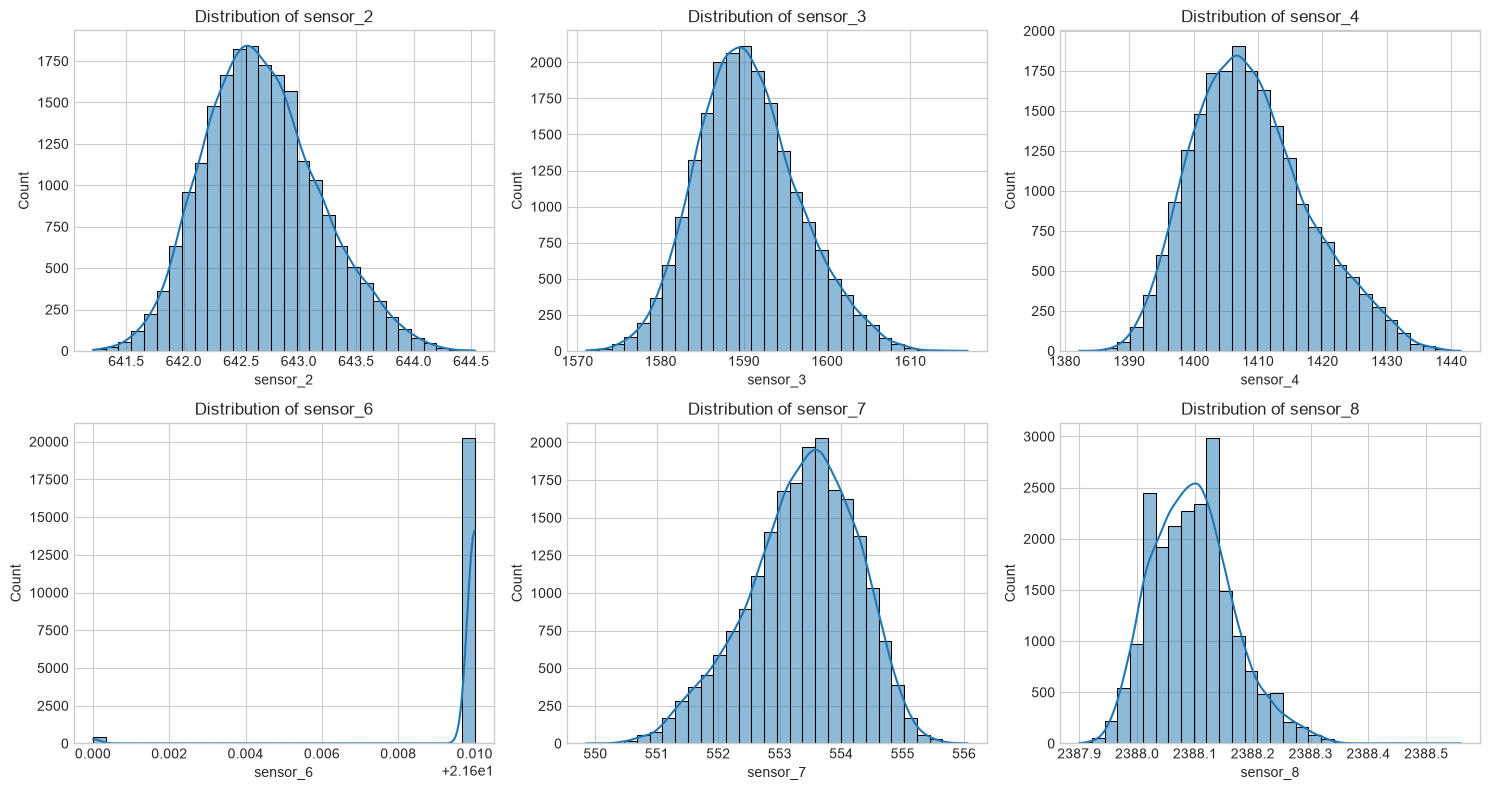

In [4]:
sensors = [c for c in train_df.columns if c.startswith('sensor_')][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flatten()):
    if i < len(sensors):
        sns.histplot(train_df[sensors[i]], bins=30, kde=True, ax=ax)
        ax.set_title(f'Distribution of {sensors[i]}')
plt.tight_layout()
os.makedirs('reports/eda_plots', exist_ok=True)
plt.savefig('reports/eda_plots/sensor_distributions.png')
plt.show()

## 4. Degradation Curves
Let's look at how sensor 2 degrades over time for the first 5 engines. The color changes as it approaches failure (RUL = 0).

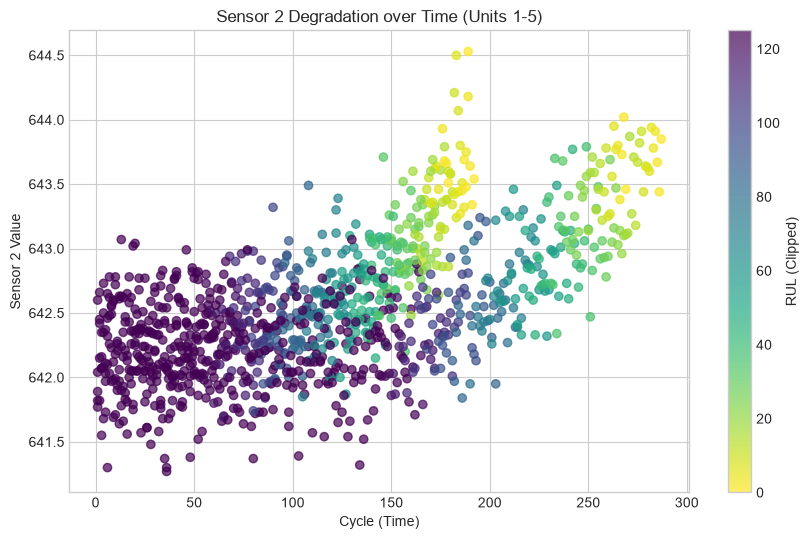

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
for unit_id in range(1, 6):
    unit_data = train_df[train_df['unit'] == unit_id]
    scatter = ax.scatter(unit_data['cycle'], unit_data['sensor_2'], 
                         c=unit_data['RUL_clipped'], cmap='viridis_r', alpha=0.7)

plt.colorbar(scatter, label='RUL (Clipped)')
plt.xlabel('Cycle (Time)')
plt.ylabel('Sensor 2 Value')
plt.title('Sensor 2 Degradation over Time (Units 1-5)')
plt.savefig('reports/eda_plots/degradation_curves.png')
plt.show()

## 5. Correlation Heatmap
Which sensors are most correlated with the Remaining Useful Life (RUL)?

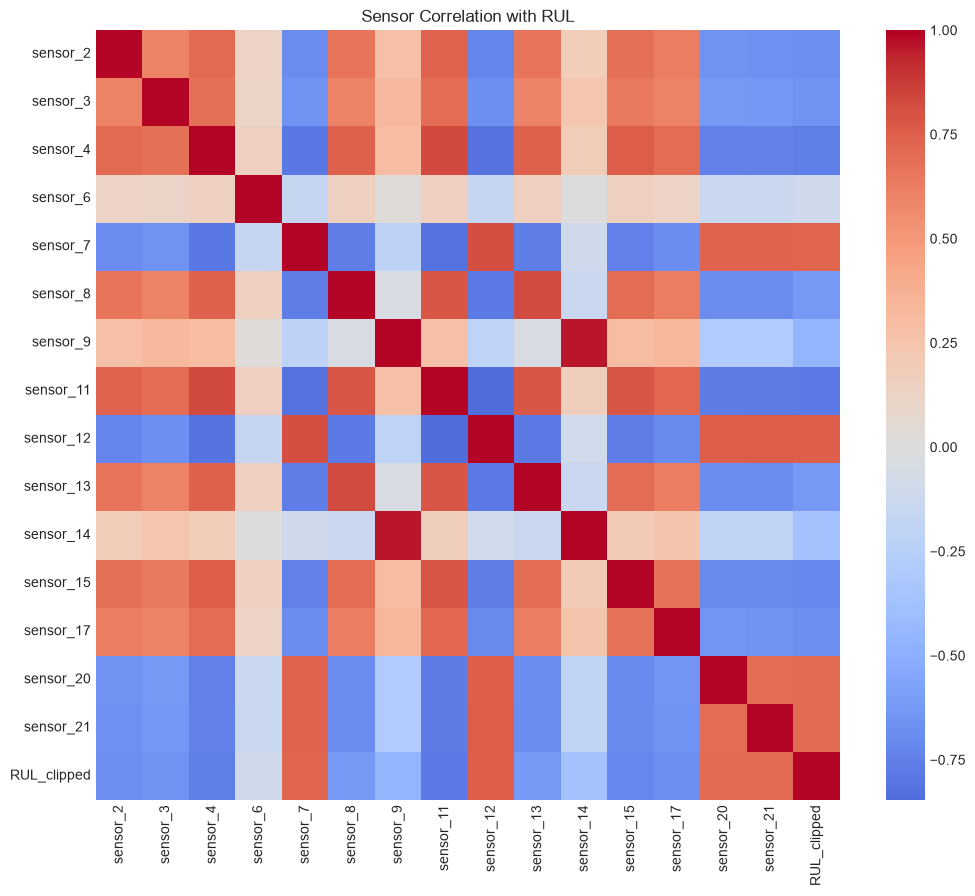

,Absolute Correlation with RUL
sensor_11,0.775230
sensor_4,0.757157
sensor_12,0.748870
sensor_7,0.733021
sensor_15,0.720858
sensor_21,0.707334
sensor_20,0.704626
sensor_17,0.680829
sensor_2,0.678458
sensor_3,0.655030


In [6]:
corr_cols = [c for c in train_df.columns if c.startswith('sensor_')] + ['RUL_clipped']
corr_matrix = train_df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Sensor Correlation with RUL')
plt.savefig('reports/eda_plots/correlation_heatmap.png')
plt.show()

# Ranked Table
rul_corrs = corr_matrix['RUL_clipped'].drop('RUL_clipped').abs().sort_values(ascending=False)
display(rul_corrs.to_frame('Absolute Correlation with RUL'))

## 6. Run Full Pipeline
Now we execute the reusable pipeline, which handles Operating Regimes (KMeans), Feature Engineering (Rolling stats), and computes the Health Index. It exports the dataset for downstream modeling.

In [7]:
# Process FD001 completely
processed_train, processed_test, hi_model = process_dataset('FD001')

[FD001] Train shape: (20631, 26), Test shape: (13096, 26)
[FD001] Train missing values: 0
[FD001] Test missing values: 0
[FD001] Dropping flatline sensors: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Detected 1 operating regimes.


[FD001] Pipeline completed successfully.
Output rows - Train: 20631, Test: 13096
Health Index Range - Train: [0.1760, 0.8003]


## 7. Health Index Validation
The Health Index should trend from ~1 (healthy) to 0 (failure). Let's plot the average Health Index vs. Normalized Life Percentage across all engines.

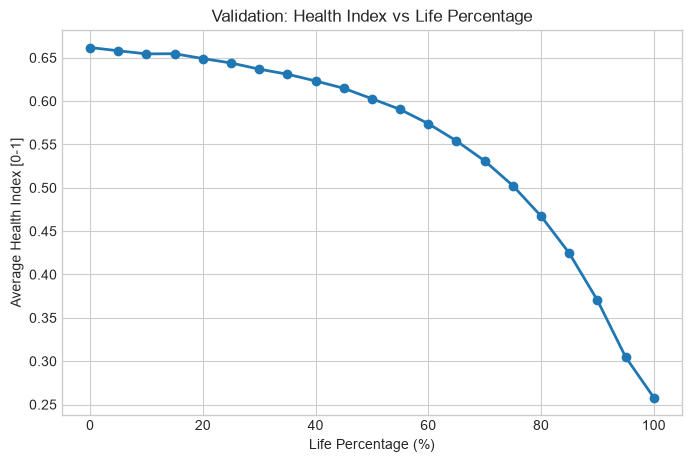

In [8]:
# Normalize life percentage per unit
def assign_life_pct(df):
    max_cycles = df.groupby('unit')['cycle'].max()
    df = df.merge(max_cycles.rename('max_cycle'), on='unit')
    df['life_pct'] = (df['cycle'] / df['max_cycle']) * 100
    df.drop(columns='max_cycle', inplace=True)
    return df

processed_train = assign_life_pct(processed_train)

# Bin into 5% intervals
processed_train['life_pct_bin'] = (processed_train['life_pct'] // 5) * 5
hi_trend = processed_train.groupby('life_pct_bin')['health_index'].mean()

plt.figure(figsize=(8, 5))
plt.plot(hi_trend.index, hi_trend.values, marker='o', linewidth=2)
plt.xlabel('Life Percentage (%)')
plt.ylabel('Average Health Index [0-1]')
plt.title('Validation: Health Index vs Life Percentage')
plt.grid(True)
plt.savefig('reports/eda_plots/health_index_validation.png')
plt.show()